The `event_alignment_ED` is basically an O(N×M) dynamic programming procedure, and is implemented as a nested for-loop. For a Bach fugue with roughly 1,400 events on each side, this already amounts to close to 2 million cell computations. For a substantially longer piece such as a Liszt piano sonata (~16,000 notes), the same recursion would require on the order of 2.5×10⁸ cell computations. Consider that students' practice is usually not that long as the sonata, `max_notes = 3500` was introduced as a hard cut-off to skip such pieces during evaluation.

In order to make the evaluation more comprehensive and improve the algorithm, can consider optimisation methods such as:

**Precomputes the whole cost matrix:**
- using numpy broadcasting for note-vs-note pairs, instead of calling compute_event_cost() once per cell in a pure Python loop. 
- chord vs chord: encode each chord as a 12-dimensional pitch-class binary vector, then compute all pairwise Hamming distances using broadcasting
- note vs chord (type mismatch): fill directly with `gap_penalty`


**Add a band around the diagonal** (future work)
- See Muller's book section 3.2.2.3 (Sakoe-Chiba band used in DTW), instead of filling the whole (N+1) x (M+1) matrix, this constrained version only fills a band around the diagonal. This is safe as long as the student performance is not wildly different in length from the reference (which is true in almost all practice scenarios). Cells outside the band are treated as "too expensive", so the aligner will never choose a path through them.

**Numba** (future work)

**Multiprocessing** during algorithm evaluation with many MIDI files

In [10]:
import json
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt

from evaluation_function.compare_MIDI import (
    compute_event_cost,
    group_notes_into_events,
    normalize_start_times,
    event_alignment_ED,
    DEFAULT_GAP_PENALTY,
)

In [11]:
def build_cost_matrix(response_events, ref_events, gap_penalty=DEFAULT_GAP_PENALTY):
    """
    Precompute the full (N x M) event-alignment cost matrix using vectorised
    NumPy broadcasting, instead of calling compute_event_cost() one cell at a
    time inside a Python loop. This also removes the redundant cost
    computation that used to happen a second time during backtracking.

    Args:
        response_events: list of event dicts (from group_notes_into_events)
        ref_events: list of event dicts (from group_notes_into_events)
        gap_penalty: cost used when event types (note vs chord) do not match

    Returns:
        numpy array of shape (N, M): cost of aligning each response event
        to each reference event, matching compute_event_cost() exactly.
    """
    N = len(response_events)
    M = len(ref_events)

    # Build simple per-event arrays: is this event a chord, and (if it is a
    # single note) what is its pitch.
    res_is_chord = np.array([event["event_type"] == "chord" for event in response_events])
    ref_is_chord = np.array([event["event_type"] == "chord" for event in ref_events])

    res_pitch = np.array([
        event["notes"][0]["pitch"] if event["event_type"] == "note" else 0
        for event in response_events
    ])
    ref_pitch = np.array([
        event["notes"][0]["pitch"] if event["event_type"] == "note" else 0
        for event in ref_events
    ])

    # Note-vs-note cost: vectorised absolute pitch difference for every pair.
    # Shape (N, 1) - shape (1, M) broadcasts to (N, M)
    note_cost_matrix = np.abs(res_pitch.reshape(N, 1) - ref_pitch.reshape(1, M))

    # Chord-vs-chord cost: build a 12-dim binary pitch-class vector per chord,
    # then compute Hamming distance for every pair using broadcasting.
    res_pitch_vector = np.zeros((N, 12), dtype=int)
    for i in range(N):
        if res_is_chord[i]:
            for note in response_events[i]["notes"]:
                res_pitch_vector[i, note["pitch"] % 12] = 1

    ref_pitch_vector = np.zeros((M, 12), dtype=int)
    for j in range(M):
        if ref_is_chord[j]:
            for note in ref_events[j]["notes"]:
                ref_pitch_vector[j, note["pitch"] % 12] = 1

    # (N, 1, 12) vs (1, M, 12) broadcasts to (N, M, 12); summing the last
    # axis gives the Hamming distance for every (response, ref) pair at once.
    differs = res_pitch_vector.reshape(N, 1, 12) != ref_pitch_vector.reshape(1, M, 12)
    chord_cost_matrix = differs.sum(axis=2)

    # Type-mismatch mask: True where one side is a note and the other a chord.
    type_mismatch = res_is_chord.reshape(N, 1) != ref_is_chord.reshape(1, M)
    both_chords = res_is_chord.reshape(N, 1) & ref_is_chord.reshape(1, M)

    # Combine the three cases -- np.where(condition, true, false)
    cost_matrix = np.where(
        type_mismatch,
        gap_penalty,
        np.where(both_chords, chord_cost_matrix, note_cost_matrix),
    )

    return cost_matrix.astype(int)


def event_alignment_ED_vectorised(response_events, ref_events, gap_penalty=DEFAULT_GAP_PENALTY):
    """
    Same algorithm as the production event_alignment_ED(), but the N x M
    substitution costs are looked up from a precomputed cost matrix instead
    of being recomputed on every DP cell and again during backtracking.

    Args:
        response_events: list of event dicts from group_notes_into_events
        ref_events: list of event dicts from group_notes_into_events
        gap_penalty: cost of leaving an event unaligned (insertion/deletion)

    Returns:
        operations: list of operation dicts, same format as event_alignment_ED()
        D: accumulated cost matrix, shape (N+1, M+1)
    """
    if "event_type" not in response_events[0]:
        response_events = group_notes_into_events(response_events)
    if "event_type" not in ref_events[0]:
        ref_events = group_notes_into_events(ref_events)

    N = len(response_events)
    M = len(ref_events)

    # Precompute every substitution cost once, instead of calling
    # compute_event_cost() inside the double loop below.
    cost_matrix = build_cost_matrix(response_events, ref_events, gap_penalty)

    D = np.zeros((N + 1, M + 1), dtype=int)
    for n in range(1, N + 1):
        D[n, 0] = n * gap_penalty
    for m in range(1, M + 1):
        D[0, m] = m * gap_penalty

    for n in range(1, N + 1):
        for m in range(1, M + 1):
            replace_cost = cost_matrix[n - 1, m - 1]
            D[n, m] = min(
                D[n - 1, m - 1] + replace_cost,
                D[n - 1, m] + gap_penalty,
                D[n, m - 1] + gap_penalty,
            )

    operations = []
    n, m = N, M
    while n > 0 or m > 0:
        if n == 0:
            operations.append({
                "type": "missing",
                "response_idx": None,
                "reference_idx": m - 1,
                "cost": gap_penalty,
            })
            m -= 1
        elif m == 0:
            operations.append({
                "type": "extra",
                "response_idx": n - 1,
                "reference_idx": None,
                "cost": gap_penalty,
            })
            n -= 1
        else:
            replace_cost = cost_matrix[n - 1, m - 1]
            diag = D[n - 1, m - 1] + replace_cost
            up = D[n - 1, m] + gap_penalty
            left = D[n, m - 1] + gap_penalty
            min_cost = min(diag, up, left)

            if min_cost == diag:
                operations.append({
                    "type": "match" if replace_cost == 0 else "replacement",
                    "response_idx": n - 1,
                    "reference_idx": m - 1,
                    "cost": int(replace_cost),
                })
                n, m = n - 1, m - 1
            elif min_cost == up:
                operations.append({
                    "type": "extra",
                    "response_idx": n - 1,
                    "reference_idx": None,
                    "cost": gap_penalty,
                })
                n -= 1
            else:
                operations.append({
                    "type": "missing",
                    "response_idx": None,
                    "reference_idx": m - 1,
                    "cost": gap_penalty,
                })
                m -= 1

    operations.reverse()
    return operations, D

**Verify Equivalence with test cases**

In [17]:
cwd = os.getcwd()
dir = os.path.dirname(cwd)
TEST_CASE_PATH = os.path.join(dir, "data", "longMIDIsequence.json")

# Fall back to the current directory if the notebook is run from elsewhere.
if not os.path.exists(TEST_CASE_PATH):
    TEST_CASE_PATH = "longMIDIsequence.json"

with open(TEST_CASE_PATH) as f:
    test_case_data = json.load(f)

test_cases = test_case_data["test_cases"]
print("Loaded", len(test_cases), "test cases:")
for case in test_cases:
    print(" -", case["name"], "(" + case["category"] + ")")

Loaded 14 test cases:
 - twinkle_perfect (long_melody)
 - twinkle_scattered_errors (long_melody)
 - twinkle_repeated_note_correct (repeated_notes)
 - twinkle_repeated_note_missing (repeated_notes)
 - twinkle_repeated_note_extra (repeated_notes)
 - twinkle_hesitation_mid_phrase (hesitation)
 - twinkle_hesitation_plus_missing (hesitation)
 - twinkle_long_break_no_notes_lost (long_break)
 - twinkle_long_break_with_skip (long_break)
 - chord_all_correct (broken_chord)
 - chord_one_wrong_note (broken_chord)
 - chord_entirely_missing (broken_chord)
 - chord_arpeggiated_within_window (broken_chord)
 - chord_arpeggiated_beyond_window (broken_chord)


In [18]:
all_passed = True

for case in test_cases:
    response_notes = normalize_start_times(case["response"]["notes"])
    ref_notes = normalize_start_times(case["reference"]["notes"])
    response_events = group_notes_into_events(response_notes)
    ref_events = group_notes_into_events(ref_notes)

    production_ops, production_D = event_alignment_ED(response_events, ref_events)
    vectorised_ops, vectorised_D = event_alignment_ED_vectorised(response_events, ref_events)

    ops_match = production_ops == vectorised_ops
    matrix_match = np.array_equal(production_D, vectorised_D)
    passed = ops_match and matrix_match

    if not passed:
        all_passed = False

    status = "PASSED" if passed else "FAILED"
    print(status, "-", case["name"])

print()
if all_passed:
    print("ALL TEST CASES PASSED: vectorised alignment is identical to production.")
else:
    print("Some test cases failed, see above.")

PASSED - twinkle_perfect
PASSED - twinkle_scattered_errors
PASSED - twinkle_repeated_note_correct
PASSED - twinkle_repeated_note_missing
PASSED - twinkle_repeated_note_extra
PASSED - twinkle_hesitation_mid_phrase
PASSED - twinkle_hesitation_plus_missing
PASSED - twinkle_long_break_no_notes_lost
PASSED - twinkle_long_break_with_skip
PASSED - chord_all_correct
PASSED - chord_one_wrong_note
PASSED - chord_entirely_missing
PASSED - chord_arpeggiated_within_window
PASSED - chord_arpeggiated_beyond_window

ALL TEST CASES PASSED: vectorised alignment is identical to production.


In [ ]:
def make_random_notes(count, chord_probability=0.15, seed=0):
    """
    Generate a random note stream for stress-testing, occasionally grouping
    several notes into a chord (same onset time) to exercise the chord-vs-chord
    and chord-vs-note code paths.

    Args:
        count: int, approximate number of notes to generate
        chord_probability: float, chance that a given onset becomes a chord
        seed: int, random seed for reproducibility

    Returns:
        list of note dicts with keys pitch, start, duration
    """
    rng = random.Random(seed)
    notes = []
    t = 0.0
    while len(notes) < count:
        t += rng.uniform(0.2, 0.6)
        if rng.random() < chord_probability:
            chord_size = rng.choice([2, 3])
            root = rng.randint(48, 80)
            offsets = rng.sample([0, 3, 4, 7, 8, 10], chord_size - 1)
            pitches = [root] + [root + offset for offset in offsets]
            for pitch in pitches:
                notes.append({"pitch": pitch, "start": t, "duration": 0.4})
        else:
            notes.append({"pitch": rng.randint(48, 84), "start": t, "duration": 0.4})
    return notes[:count]


for size in [50, 300, 800]:
    res_notes = make_random_notes(size, seed=1)
    ref_notes_r = make_random_notes(size, seed=2)
    res_events = group_notes_into_events(normalize_start_times(res_notes))
    ref_events_r = group_notes_into_events(normalize_start_times(ref_notes_r))

    production_ops, production_D = event_alignment_ED(res_events, ref_events_r)
    vectorised_ops, vectorised_D = event_alignment_ED_vectorised(res_events, ref_events_r)
    match = production_ops == vectorised_ops and np.array_equal(production_D, vectorised_D)

    print("note_count~" + str(size), " events=" + str(len(res_events)) + "x" + str(len(ref_events_r)), " match=" + str(match))

print()
print("If all lines above say match=True, the vectorised version is verified correct at scale.")


note_count~50  events=41x43  match=True
note_count~300  events=246x240  match=True
note_count~800  events=657x651  match=True

If all lines above say match=True, the vectorised version is verified correct at scale.


**Timing Comparison**

Measure the runtime of both implementations at several data sizes, and plot "time vs. piece size" 

In [20]:
sizes = [50, 100, 200, 400, 800, 1500]
old_times = []
new_times = []

for size in sizes:
    res_notes = make_random_notes(size, seed=3)
    ref_notes_r = make_random_notes(size, seed=4)
    res_events = group_notes_into_events(normalize_start_times(res_notes))
    ref_events_r = group_notes_into_events(normalize_start_times(ref_notes_r))

    t0 = time.perf_counter()
    event_alignment_ED(res_events, ref_events_r)
    t1 = time.perf_counter()
    event_alignment_ED_vectorised(res_events, ref_events_r)
    t2 = time.perf_counter()

    old_time = t1 - t0
    new_time = t2 - t1
    old_times.append(old_time)
    new_times.append(new_time)

    speedup = old_time / new_time if new_time > 0 else float("inf")
    print("N=M~" + str(size) + ": production=" + format(old_time, ".4f") + "s  vectorised=" + format(new_time, ".4f") + "s  speedup=" + format(speedup, ".1f") + "x")

N=M~50: production=0.0013s  vectorised=0.0023s  speedup=0.6x
N=M~100: production=0.0047s  vectorised=0.0050s  speedup=0.9x
N=M~200: production=0.0200s  vectorised=0.0170s  speedup=1.2x
N=M~400: production=0.1051s  vectorised=0.0684s  speedup=1.5x
N=M~800: production=0.3403s  vectorised=0.2814s  speedup=1.2x
N=M~1500: production=1.2428s  vectorised=1.0064s  speedup=1.2x


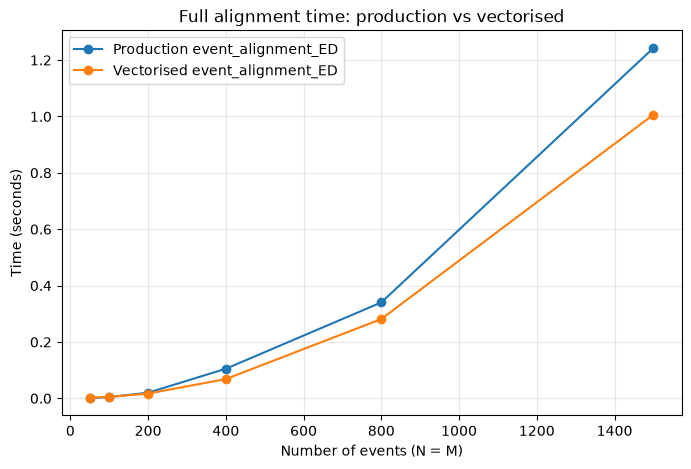

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(sizes, old_times, marker="o", label="Production event_alignment_ED")
plt.plot(sizes, new_times, marker="o", label="Vectorised event_alignment_ED")
plt.xlabel("Number of events (N = M)")
plt.ylabel("Time (seconds)")
plt.title("Full alignment time: production vs vectorised")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()